# RLC Network with Initial Conditions (Example 13)

## Switch from 1 equivalent network to another at t=0

* Conditions prior to $t=0$ lead to initial conditions that must be included

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# Course utilities (do not modify this cell)
# Generated by post-canvas-notebooks. Edits above the marker are overwritten.
from pathlib import Path
import sys


def _find_courseutils():
    """Find courseutils no matter where the course repo was cloned."""
    here = Path.cwd().resolve()

    for parent in [here] + list(here.parents):
        for candidate in (parent / "courseutils",
                          parent / "Signals_and_Systems" / "courseutils"):
            if (candidate / "basic_material.py").is_file():
                return candidate.resolve()

    raise FileNotFoundError(
        "Could not find the 'courseutils' folder. Clone "
        "https://github.com/mit-acl/Signals_and_Systems and run this "
        "notebook from inside the cloned repository, then restart the kernel."
    )


COURSEUTILS_DIR = _find_courseutils()

# courseutils is used both as a folder of modules and as a package,
# since control_materials does "import courseutils.basic_material",
# so the folder and its parent both go on the path.
for _location in (COURSEUTILS_DIR.parent, COURSEUTILS_DIR):
    if str(_location) not in sys.path:
        sys.path.insert(0, str(_location))

for _folder in ("data", "figs"):
    Path(_folder).mkdir(exist_ok=True)

# --- end course setup ---

import basic_material as bm
print("Basic Material version:", bm.__version__)
bm.setup_environment()

import control_materials as cm
print("Control Material version:", cm.__version__)
cm.setup_environment()

Basic Material version: 16.002-0.1


Control Material version: 16.002-0.1


In [3]:
import warnings
warnings.filterwarnings(
    "ignore",
    message="pkg_resources is deprecated as an API.*",
    category=UserWarning,
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

colors = bm.get_colors()
j = complex(0,1)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnchoredText
import sympy as sp

import control as ct
import control.matlab as cmat

try: 
    from sympy import lambdify, oo, Symbol, integrate, Heaviside, plot, Piecewise
except:
    %pip install sympy
from sympy import *
from sympy import lambdify, oo, Symbol, integrate, Heaviside, plot, Piecewise
from sympy import fourier_transform, exp, inverse_fourier_transform, sympify, DiracDelta, sinc, sin, cos, arg, atan2, re, cos, exp_polar, pi
from sympy.abc import A,B,t,f 
from sympy import re, im 

from lcapy import Circuit, j, omega, s, exp
from lcapy import R, C, L

from IPython.display import display, Javascript
display(Javascript('document.title = "RLC Network with Initial Conditions";'))


<IPython.core.display.Javascript object>

Equivalent Circuit before switch closed at time t=0



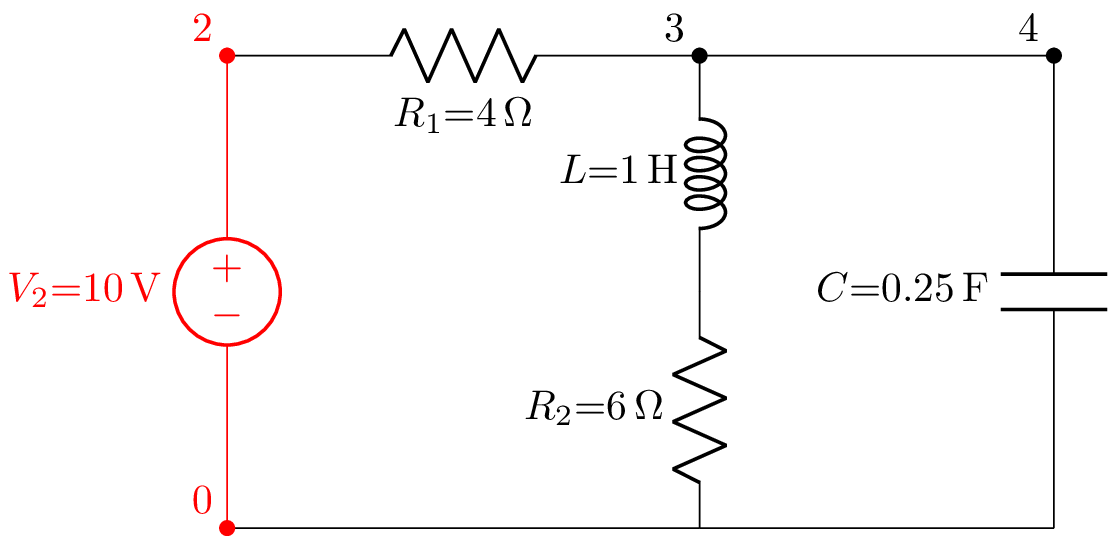



Equivalent Circuit after switch closed at time t=0



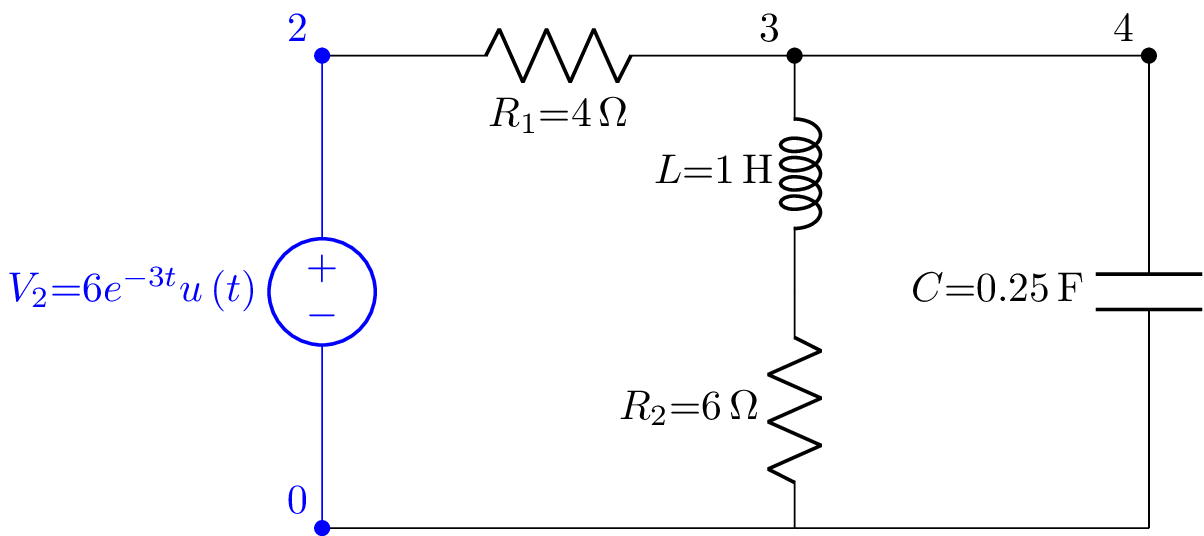

In [4]:
Vin = 10
RR1 = 4
RR2 = 6
CC = 1/4
LL = 1

# first network with a dc input t < 0
cct8_0 = Circuit("""
V2 2 0 dc 10; down, color=red
R1 2 3 RR1 ; right=2
L 3 1_3 L ; down=1
R2 1_3 0_3 RR2 ; down=1
W 3 4; right=1.5
C 4 0_4 C; down=1 
W 0 0_3; right
W 0_3 0_4; right
""")

# second network with a ac input t >= 0 
cct8_1 = Circuit("""
V2 2 0 {6*exp(-3*t)*Heaviside(t)}; down, color=blue
R1 2 3 RR1 ; right=2
L 3 1_3 L ; down=1
R2 1_3 0_3 RR2 ; down=1
W 3 4; right=1.5
C 4 0_4 C; down=1 
W 0 0_3; right
W 0_3 0_4; right
""")

cct8_0a = cct8_0.subs({'C': CC, 'L': LL, 'RR1': RR1, 'RR2': RR2})
cct8_1a = cct8_1.subs({'C': CC, 'L': LL, 'RR1': RR1, 'RR2': RR2})

cct8_1a = cct8_1a.initialize(cct8_0a, 0)

print('Equivalent Circuit before switch closed at time t=0\n')
cct8_0a.draw()
print('\n\nEquivalent Circuit after switch closed at time t=0\n')
cct8_1a.draw()

In [5]:
tt = np.linspace(0, 10, 100)
tneg = np.linspace(-5, 0, 100)
vc_neg = cct8_0a.C.v.evaluate(tneg)
vc_pos = cct8_1a.C.v.evaluate(tt)
ilneg = cct8_0a.L.i.evaluate(tneg)
il = cct8_1a.L.i.evaluate(tt)

In [6]:
#RR1 = 3
#RR2 = 5
#CC = 1/3
#LL = 1
Vs0 = 6
V0 = 10
alpha = 3

a = (LL + RR1*RR2*CC)/(RR1*CC*LL)
b = (RR1 + RR2)/(RR1*CC*LL)

disc = a**2 - 4*b
r1 = (-a + np.sqrt(disc))/2
r2 = (-a - np.sqrt(disc))/2

I0 = V0/(RR1 + RR2)
Vc0 = V0*RR2/(RR1 + RR2)
Vcdot0 = ((Vs0 - Vc0)/RR1 - I0)/CC

C3 = (
    -alpha*Vs0/(RR1*CC)
    + Vs0*RR2/(RR1*CC*LL)
)/(alpha**2 - alpha*a + b)

C1 = (Vcdot0 + alpha*C3 - r2*(Vc0 - C3))/(r1 - r2)
C2 = Vc0 - C3 - C1

tall = np.concatenate((tneg, tt))
vc_analytic = np.where(
    tall >= 0,
    C1*np.exp(r1*tall) + C2*np.exp(r2*tall) + C3*np.exp(-alpha*tall),
    Vc0
)

print([r1, r2, C1, C2, C3])

[-2.0, -5.0, 14.666666666666666, 0.3333333333333339, -9.0]


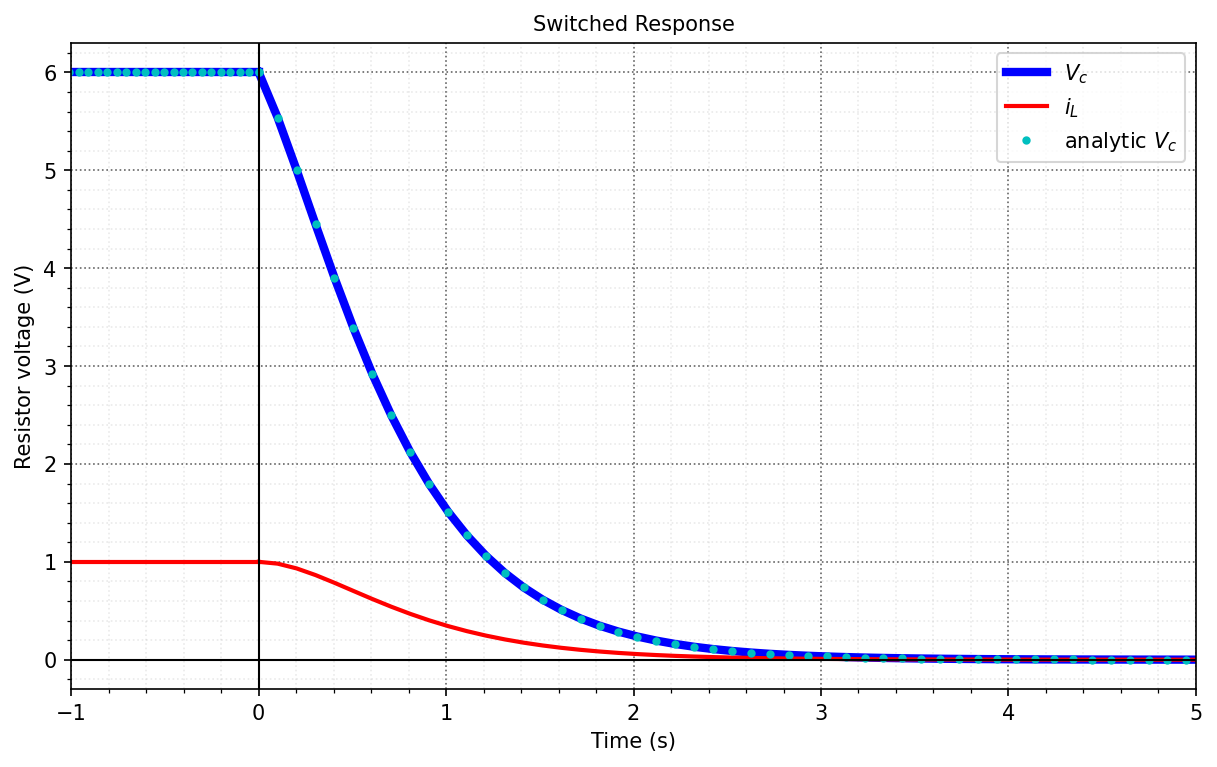

In [7]:
fig = plt.figure(figsize=(8, 5),dpi=150,constrained_layout = True)
ax = fig.add_subplot(111, title='Switched Response')
ax.plot(tt, vc_pos, 'b-', linewidth=4, label='$V_c$')
ax.plot(tneg, vc_neg, 'b-', linewidth=4)
ax.plot(tneg, ilneg, linewidth=2, color='red', label='$i_L$')
ax.plot(tt, il, linewidth=2, color='red')
ax.plot(tall, vc_analytic, 'c.', label='analytic $V_c$')
ax.set_xlabel('Time (s)')
ax.set_xlim(-1,5)
ax.set_ylabel('Resistor voltage (V)');
bm.nicegrid(ax)
plt.legend()
plt.show()

## Derive expression for the current - not easy to handle H(t) here

In [8]:
from sympy.integrals.transforms import laplace_transform 
from sympy.integrals.transforms import inverse_laplace_transform 
import sympy as sp 
import numpy as np 
from sympy.abc import a, t, x, s, X, g, G 
from sympy import DiracDelta
init_printing(use_unicode=True)

svc, svs, sil = symbols('svc svs sil', cls = Function) 
svs = 6*sp.exp(-3*t)*Heaviside(t) 

In [9]:
# capacitor voltage as determined in the notes
svc = (44/3*sp.exp(-2*t) + 1/3*sp.exp(-5*t) -9*sp.exp(-3*t))*Heaviside(t) + 6*(1-Heaviside(t))

In [10]:
# find derivative of the capac voltage and confirm correct value
svcdot = svc.diff(t)
svcdot0_pos = svcdot.subs(t,0+np.finfo(float).eps)
print(f"The value of this should be -4. {svcdot0_pos= : 4.3f}") 

The value of this should be -4. svcdot0_pos= -4.000


In [11]:
# Positive time solution for the capacitor voltage derivative
sp.simplify(svcdot.subs(Heaviside(t), 1).subs(sp.DiracDelta(t), 0))

In [12]:
svc_left = 6
svc_right = (
    sp.Rational(44, 3)
    + sp.Rational(1, 3)
    - 9
)

sp.simplify(svc_right - svc_left)


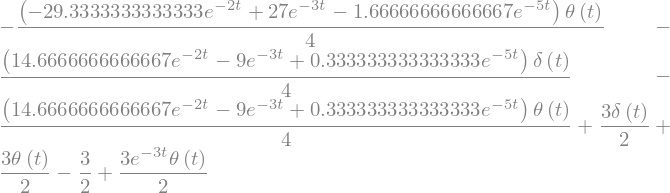

In [13]:
# equations from notes
# first term only valid for pos time - added second term for negative time
sil = (svs/4-svcdot/4-svc/4)
sil

In [14]:
# find initial i to confirm that it is 1, as required
sil_pos = sil.subs(t,0+np.finfo(float).eps) 
print(f"The value of this should be 1. {sil_pos= : 4.3f}")

The value of this should be 1. sil_pos=  1.000


In [15]:
H = Heaviside

svc = (
    sp.Rational(44, 3)*sp.exp(-2*t)
    + sp.Rational(1, 3)*sp.exp(-5*t)
    - 9*sp.exp(-3*t)
)*H(t) + 6*(1 - H(t))

svs = 6*sp.exp(-3*t)*H(t)

svcdot = sp.diff(svc, t)

sil = sp.Rational(1, 4)*svs - sp.Rational(1, 4)*svcdot - sp.Rational(1, 4)*svc

sil_s = sp.collect(sp.simplify(sp.expand(sil)), H(t))
sil_s

sil.subs(H(t), 0).subs(sp.DiracDelta(t), 0)

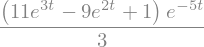

In [16]:
sp.simplify(sil.subs(H(t), 1).subs(sp.DiracDelta(t), 0))

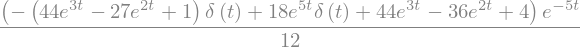

In [17]:
H = sp.Heaviside

sil_s = sp.collect(sp.simplify(sp.expand(sil)), H(t))
sil_s

sp.simplify(sil.subs(sp.Heaviside(t), 1))

In [18]:
# convert sympy output to matplotlib format
t_all = np.linspace(-1, 5, 1000)
IL = np.zeros(len(t_all))
for n,t_test in enumerate(t_all):
    IL[n] = sil.subs(t,t_test)

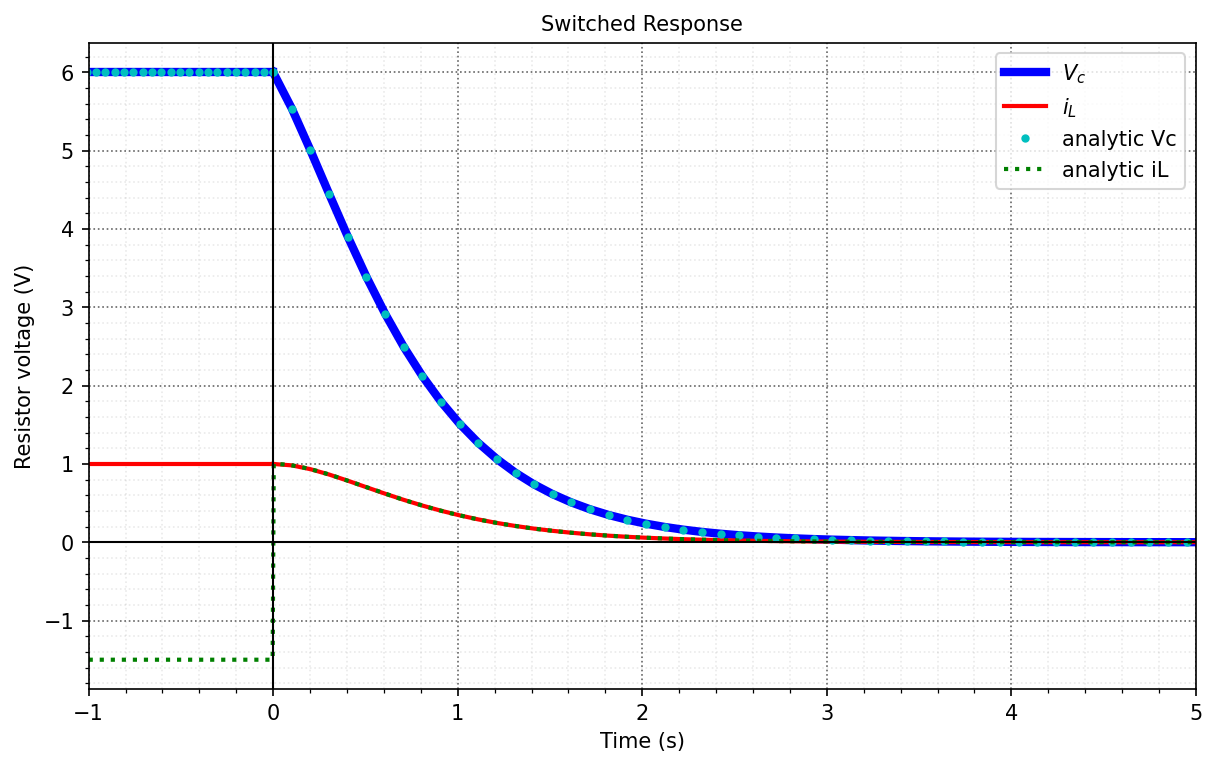

In [19]:
fig = plt.figure(figsize=(8, 5),dpi=150,constrained_layout = True)
ax = fig.add_subplot(111, title='Switched Response')
ax.plot(tt, vc_pos, 'b-', linewidth=4, label='$V_c$')
ax.plot(tneg, vc_neg, 'b-', linewidth=4)
ax.plot(tneg, ilneg, linewidth=2, color='red', label='$i_L$')
ax.plot(tt, il, linewidth=2, color='red')
ax.plot(tt, 44/3*np.exp(-2*tt)+np.exp(-5*tt)/3-9*np.exp(-3*tt), 'c.', label='analytic Vc')
ax.plot(tneg, tneg*0+6, 'c.')
plt.plot(t_all,IL, 'g:', label='analytic iL')

ax.set_xlabel('Time (s)')
ax.set_xlim(-1,5)
ax.set_ylabel('Resistor voltage (V)');
bm.nicegrid()
plt.legend()
plt.show()